# Project 1: Temperature Prediction Using Linear Regression

## Objective

To predict the temperature of the next hour using the temperatures of the current hour and the previous two hours by implementing a Linear Regression model in Python.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [12]:
import pandas as pd

df = pd.read_csv(
    '/content/saga_temp.csv',
    encoding='cp932',
    header=[1,2,3]
)

df.head()

Unnamed: 0_level_0                 佐賀          
                年月日時              気温(℃)          
  Unnamed: 0_level_2 Unnamed: 1_level_2 品質情報 均質番号
0   2025/6/8 1:00:00               21.1    8    1
1   2025/6/8 2:00:00               21.1    8    1
2   2025/6/8 3:00:00               21.0    8    1
3   2025/6/8 4:00:00               20.6    8    1
4   2025/6/8 5:00:00               20.7    8    1

In [13]:
# Create a simpler dataframe
temp_df = pd.DataFrame()

# Extract Date-Time column
temp_df['Datetime'] = df.iloc[:,0]

# Extract Temperature column
temp_df['Temperature'] = df.iloc[:,1]

temp_df.head()

,Datetime,Temperature
0,2025/6/8 1:00:00,21.1
1,2025/6/8 2:00:00,21.1
2,2025/6/8 3:00:00,21.0
3,2025/6/8 4:00:00,20.6
4,2025/6/8 5:00:00,20.7


In [14]:
# Create input features
temp_df['T(t)'] = temp_df['Temperature']
temp_df['T(t-1)'] = temp_df['Temperature'].shift(1)
temp_df['T(t-2)'] = temp_df['Temperature'].shift(2)

# Create target column
temp_df['Target'] = temp_df['Temperature'].shift(-1)

# Remove rows containing NaN values
temp_df.dropna(inplace=True)

# Reset index
temp_df.reset_index(drop=True, inplace=True)

temp_df.head()

,Datetime,Temperature,T(t),T(t-1),T(t-2),Target
0,2025/6/8 3:00:00,21.0,21.0,21.1,21.1,20.6
1,2025/6/8 4:00:00,20.6,20.6,21.0,21.1,20.7
2,2025/6/8 5:00:00,20.7,20.7,20.6,21.0,20.7
3,2025/6/8 6:00:00,20.7,20.7,20.7,20.6,21.0
4,2025/6/8 7:00:00,21.0,21.0,20.7,20.7,22.1


In [15]:
# Input features
X = temp_df[['T(t)', 'T(t-1)', 'T(t-2)']]

# Target variable
y = temp_df['Target']

# Display shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (261, 3)
y shape: (261,)


In [16]:
# Input features
X = temp_df[['T(t)', 'T(t-1)', 'T(t-2)']]

# Target variable
y = temp_df['Target']

In [17]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

LinearRegression()

In [19]:
print("Weights:", model.coef_)
print("Bias:", model.intercept_)

Weights: [ 1.33475514 -0.17910642 -0.19964478]
Bias: 1.07329799882843


In [20]:
# Predict temperatures for the test set
y_pred = model.predict(X_test)

In [21]:
results = X_test.copy()

results['Actual Temperature'] = y_test
results['Predicted Temperature'] = y_pred

results.head(10)

,T(t),T(t-1),T(t-2),Actual Temperature,Predicted Temperature
30,20.9,20.7,20.3,20.8,21.209389
143,25.8,26.2,26.0,26.0,25.626628
170,22.8,23.1,23.2,22.6,22.736598
73,19.5,19.6,20.7,19.7,19.457891
159,26.2,25.8,25.3,25.7,26.371924
252,30.8,31.0,30.5,30.8,30.542292
190,26.1,25.6,25.7,26.7,26.194412
104,22.8,22.2,21.1,22.8,23.317048
9,25.3,24.7,24.0,26.9,25.627200
186,25.3,25.1,24.9,25.6,25.375877


In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

# Root Mean Squared Error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 0.3732645720776828
Root Mean Squared Error (RMSE): 0.48962914070945024


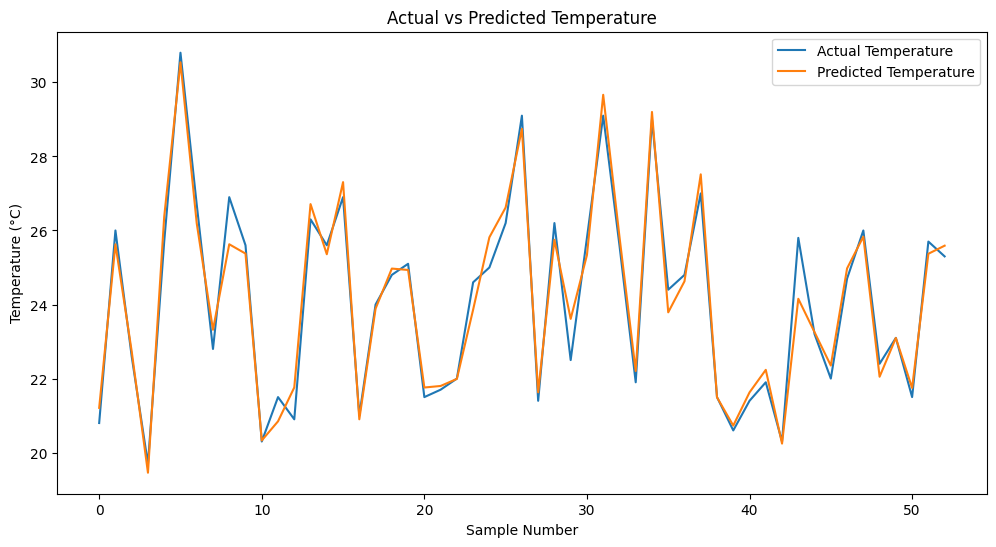

In [23]:
import matplotlib.pyplot as plt

# Create the figure
plt.figure(figsize=(12,6))

# Plot actual temperatures
plt.plot(y_test.values, label='Actual Temperature')

# Plot predicted temperatures
plt.plot(y_pred, label='Predicted Temperature')

# Labels and title
plt.xlabel('Sample Number')
plt.ylabel('Temperature (°C)')
plt.title('Actual vs Predicted Temperature')

# Show legend
plt.legend()

# Display plot
plt.show()

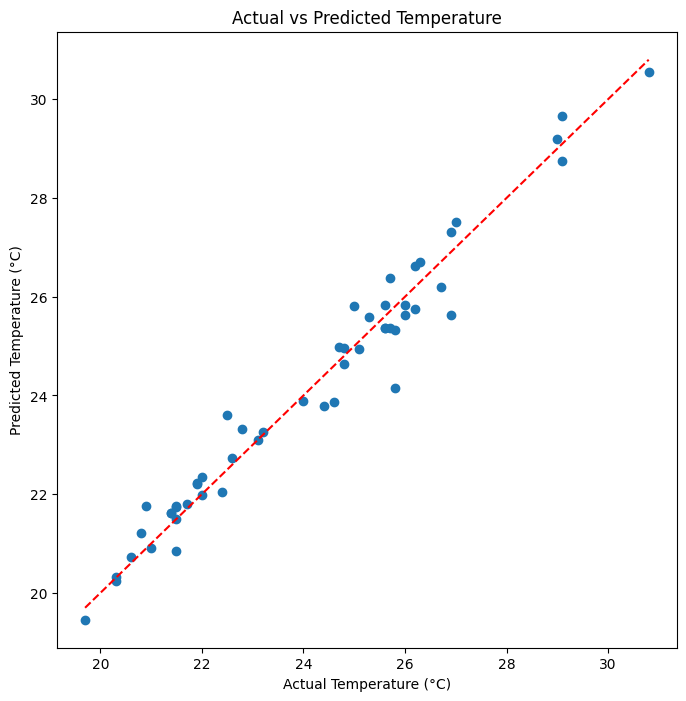

In [24]:
plt.figure(figsize=(8,8))

# Scatter plot
plt.scatter(y_test, y_pred)

# Reference line (Perfect predictions)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

# Labels and title
plt.xlabel('Actual Temperature (°C)')
plt.ylabel('Predicted Temperature (°C)')
plt.title('Actual vs Predicted Temperature')

plt.show()

In [25]:
# Calculate absolute errors
errors = np.abs(y_test - y_pred)

# Average error
average_error = np.mean(errors)

# Standard deviation of error
std_error = np.std(errors)

print("Average Error (°C):", average_error)
print("Standard Deviation (°C):", std_error)

Average Error (°C): 0.3732645720776828
Standard Deviation (°C): 0.3168757716575046


In [26]:
# Get the last three temperatures from the dataset
last_three = temp_df['Temperature'].tail(3).tolist()

print(last_three)

[27.2, 26.3, 25.0]


In [28]:
# Start with the last three observed temperatures
history = last_three.copy()

# Store future predictions
future_predictions = []

# Predict the next 48 hours
for i in range(48):

    # Prepare input for the model
    x_input = [[history[-1], history[-2], history[-3]]]

    # Predict next temperature
    next_temp = model.predict(x_input)[0]

    # Save prediction
    future_predictions.append(next_temp)

    # Add prediction to history for recursive forecasting
    history.append(next_temp)

# Display first 10 predicted temperatures
print(future_predictions[:10])

[np.float64(24.301339802985346), np.float64(23.781318156622124), np.float64(23.47188932724338), np.float64(23.291500680750673), np.float64(23.209966302931477), np.float64(23.195222487355835), np.float64(23.226160085500915), np.float64(23.28637282858888), np.float64(23.364144500544455), np.float64(23.45098962102554)]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/

In [29]:
import pandas as pd

# Create hourly timestamps for June 19 and June 20
future_times = pd.date_range(
    start='2025-06-19 00:00:00',
    periods=48,
    freq='H'
)

# Create forecast dataframe
forecast_df = pd.DataFrame({
    'Datetime': future_times,
    'Predicted Temperature (°C)': future_predictions
})

# Display first 10 predictions
forecast_df.head(10)

/tmp/ipykernel_3445/144665704.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_times = pd.date_range(


,Datetime,Predicted Temperature (°C)
0,2025-06-19 00:00:00,24.301340
1,2025-06-19 01:00:00,23.781318
2,2025-06-19 02:00:00,23.471889
3,2025-06-19 03:00:00,23.291501
4,2025-06-19 04:00:00,23.209966
5,2025-06-19 05:00:00,23.195222
6,2025-06-19 06:00:00,23.226160
7,2025-06-19 07:00:00,23.286373
8,2025-06-19 08:00:00,23.364145
9,2025-06-19 09:00:00,23.450990
